# PREDICTION — Predictive Models for Sub-3 h Failure

Which pacing features best discriminate runners who **fail** to break 3 h from those who **succeed**?

Both groups share nearly identical half-marathon splits (~1 h 28 min), so the answer lies in **second-half pacing behaviour**.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance

# ── load data ────────────────────────────────────────────────────────
df = pd.read_csv("../data/cohort_clustered.csv")
print(f"Rows: {len(df):,}")
print(f"Outcome distribution:\n{df['outcome'].value_counts()}\n")

# binary target  (1 = Failure)
df["y"] = (df["outcome"] == "Failure").astype(int)

# ── pace column list ─────────────────────────────────────────────────
PACE_COLS = [
    "pace_05k", "pace_510k", "pace_1015k", "pace_1520k",
    "pace_2025k", "pace_2530k", "pace_3035k", "pace_3540k", "pace_40End",
]

# ── feature engineering ──────────────────────────────────────────────
df["delta_first_last"] = df["pace_40End"] - df["pace_05k"]         # how much they slowed
df["delta_30_to_end"]  = df["pace_40End"] - df["pace_2530k"]       # late-race collapse

pace_first  = df[["pace_05k", "pace_510k", "pace_1015k", "pace_1520k"]].mean(axis=1)
pace_second = df[["pace_2025k", "pace_2530k", "pace_3035k", "pace_3540k", "pace_40End"]].mean(axis=1)
df["pace_ratio_second_first"] = pace_second / pace_first

# ── correlations with outcome ────────────────────────────────────────
feat_cols = [
    "pacing_cv", "pace_05k", "pace_3540k", "pace_40End",
    "delta_first_last", "delta_30_to_end", "pace_ratio_second_first",
]
corr = df[feat_cols + ["y"]].corr()["y"].drop("y").sort_values(ascending=False)
print("Feature correlations with Failure (y=1):")
print(corr.to_string(float_format="{:.3f}".format))

Rows: 9,585
Outcome distribution:
outcome
Success    7710
Failure    1875
Name: count, dtype: int64

Feature correlations with Failure (y=1):
pace_3540k                 0.750
pace_ratio_second_first    0.720
pacing_cv                  0.711
pace_40End                 0.705
delta_first_last           0.665
delta_30_to_end            0.480
pace_05k                  -0.112


## Logistic Regression

In [2]:
# ── Logistic Regression (statsmodels — proper inference) ─────────────
X = df[feat_cols].copy()
X = sm.add_constant(X)
y = df["y"]

logit_model = sm.Logit(y, X).fit(disp=False)

# ── summary table ────────────────────────────────────────────────────
print(logit_model.summary2())

# ── odds ratios with 95 % CI ────────────────────────────────────────
params = logit_model.params
conf = logit_model.conf_int()
odds = pd.DataFrame({
    "coef":      params,
    "OR":        np.exp(params),
    "OR_2.5%":   np.exp(conf[0]),
    "OR_97.5%":  np.exp(conf[1]),
    "p-value":   logit_model.pvalues,
})
print("\nOdds Ratios (OR) with 95 % CI:")
print(odds.to_string(float_format="{:.4f}".format))

# ── AUC-ROC (in-sample) ─────────────────────────────────────────────
y_prob = logit_model.predict(X)
auc = roc_auc_score(y, y_prob)
print(f"\nLogistic Regression AUC-ROC (in-sample): {auc:.4f}")

                                     Results: Logit
Model:                        Logit                    Method:                   MLE     
Dependent Variable:           y                        Pseudo R-squared:         0.959   
Date:                         2026-03-26 10:39         AIC:                      403.3654
No. Observations:             9585                     BIC:                      453.5411
Df Model:                     6                        Log-Likelihood:           -194.68 
Df Residuals:                 9578                     LL-Null:                  -4737.6 
Converged:                    0.0000                   LLR p-value:              0.0000  
No. Iterations:               35.0000                  Scale:                    1.0000  
-----------------------------------------------------------------------------------------
                          Coef.     Std.Err.      z     P>|z|      [0.025       0.975]   
------------------------------------------------

/config/.local/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Random Forest — Feature Importance

In [3]:
# ── Random Forest ─────────────────────────────────────────────────────
X_rf = df[feat_cols].values
y_rf = df["y"].values

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
)
rf.fit(X_rf, y_rf)

# ── Permutation importance (more robust than Gini) ───────────────────
perm = permutation_importance(
    rf, X_rf, y_rf,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc",
)

imp = pd.DataFrame({
    "feature":    feat_cols,
    "importance": perm.importances_mean,
    "std":        perm.importances_std,
}).sort_values("importance", ascending=False)

print("Permutation Feature Importance (AUC-ROC scoring):")
print(imp.to_string(index=False, float_format="{:.4f}".format))

# ── AUC-ROC (in-sample) ─────────────────────────────────────────────
y_prob_rf = rf.predict_proba(X_rf)[:, 1]
auc_rf = roc_auc_score(y_rf, y_prob_rf)
print(f"\nRandom Forest AUC-ROC (in-sample): {auc_rf:.4f}")

Permutation Feature Importance (AUC-ROC scoring):
                feature  importance    std
pace_ratio_second_first      0.1160 0.0020
             pace_3540k      0.0111 0.0003
               pace_05k      0.0069 0.0003
             pace_40End      0.0030 0.0003
        delta_30_to_end      0.0010 0.0001
              pacing_cv      0.0001 0.0000
       delta_first_last      0.0000 0.0000

Random Forest AUC-ROC (in-sample): 1.0000


## ROC Curve — Best Single Predictor

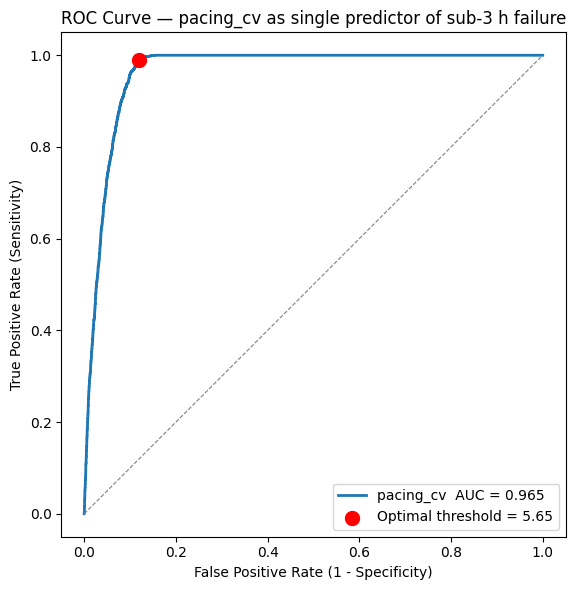


Optimal threshold (Youden J): 5.6486
Sensitivity:  0.9904
Specificity:  0.8798
Accuracy:     0.9014


In [4]:
# ── ROC Curve for pacing_cv (best single predictor) ──────────────────
fpr, tpr, thresholds = roc_curve(df["y"], df["pacing_cv"])
auc_cv = roc_auc_score(df["y"], df["pacing_cv"])

# Youden's J index → optimal threshold
J = tpr - fpr
ix_best = np.argmax(J)
thresh_best = thresholds[ix_best]
sens_best   = tpr[ix_best]
spec_best   = 1 - fpr[ix_best]

# accuracy at optimal threshold
y_pred_opt = (df["pacing_cv"] >= thresh_best).astype(int)
acc_best = (y_pred_opt == df["y"]).mean()

# ── plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"pacing_cv  AUC = {auc_cv:.3f}")
ax.plot([0, 1], [0, 1], "--", color="grey", lw=0.8)
ax.scatter(fpr[ix_best], tpr[ix_best], marker="o", s=100, color="red", zorder=5,
           label=f"Optimal threshold = {thresh_best:.2f}")
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.set_title("ROC Curve — pacing_cv as single predictor of sub-3 h failure")
ax.legend(loc="lower right")
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig("../figures/roc_pacing_cv_diagnostic.png", dpi=150)
plt.show()

print(f"\nOptimal threshold (Youden J): {thresh_best:.4f}")
print(f"Sensitivity:  {sens_best:.4f}")
print(f"Specificity:  {spec_best:.4f}")
print(f"Accuracy:     {acc_best:.4f}")

## Summary

In [5]:
# ── Consolidated findings ────────────────────────────────────────────
print("=" * 65)
print("PREDICTION NOTEBOOK — CONSOLIDATED FINDINGS")
print("=" * 65)

print(f"\nSample: {len(df):,} runners  |  Success: {(df['y']==0).sum():,}  |  Failure: {(df['y']==1).sum():,}")

print("\n--- Logistic Regression (statsmodels) ---")
print(f"  AUC-ROC (in-sample): {auc:.4f}")
sig = odds[odds["p-value"] < 0.05].drop("const", errors="ignore")
print(f"  Significant predictors (p < 0.05):")
for feat, row in sig.iterrows():
    print(f"    {feat:30s}  OR={row['OR']:.3f}  p={row['p-value']:.4f}")

print("\n--- Random Forest (permutation importance) ---")
print(f"  AUC-ROC (in-sample): {auc_rf:.4f}")
print(f"  Top-3 features:")
for _, row in imp.head(3).iterrows():
    print(f"    {row['feature']:30s}  importance={row['importance']:.4f}")

print("\n--- Best single predictor: pacing_cv ---")
print(f"  AUC-ROC:      {auc_cv:.4f}")
print(f"  Threshold:    {thresh_best:.4f}  (Youden J)")
print(f"  Sensitivity:  {sens_best:.4f}")
print(f"  Specificity:  {spec_best:.4f}")
print(f"  Accuracy:     {acc_best:.4f}")

print("\n--- Key takeaway ---")
print("  Pacing variability (CV) is the strongest single predictor of")
print("  sub-3 h failure among runners with matched half-marathon times.")
print("  Late-race pace variables (35-40 km, 40 km-End) add further")
print("  discriminative power in multivariate models.")
print("=" * 65)

PREDICTION NOTEBOOK — CONSOLIDATED FINDINGS

Sample: 9,585 runners  |  Success: 7,710  |  Failure: 1,875

--- Logistic Regression (statsmodels) ---
  AUC-ROC (in-sample): 0.9976
  Significant predictors (p < 0.05):
    pacing_cv                       OR=0.213  p=0.0000
    pace_3540k                      OR=25583542.130  p=0.0000
    delta_30_to_end                 OR=0.000  p=0.0000
    pace_ratio_second_first         OR=1198384294.473  p=0.0226

--- Random Forest (permutation importance) ---
  AUC-ROC (in-sample): 1.0000
  Top-3 features:
    pace_ratio_second_first         importance=0.1160
    pace_3540k                      importance=0.0111
    pace_05k                        importance=0.0069

--- Best single predictor: pacing_cv ---
  AUC-ROC:      0.9646
  Threshold:    5.6486  (Youden J)
  Sensitivity:  0.9904
  Specificity:  0.8798
  Accuracy:     0.9014

--- Key takeaway ---
  Pacing variability (CV) is the strongest single predictor of
  sub-3 h failure among runners with 